## Convolutional Networks

We'll check out how to build a **convolutional network** to classify CIFAR10 images. By using weight sharing - multiple units with the same weights - convolutional layers are able to learn repeated patterns in your data. For example, a unit could learn the pattern for an eye, or a face, or lower level features like edges.


In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import numpy as np
import time

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
import torch.utils.data as utils
from torchvision import datasets, transforms
from torch.utils.data.sampler import SubsetRandomSampler
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torchvision.datasets import CIFAR10

%matplotlib inline

In [3]:
label_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


def plot_images(images, cls_true, cls_pred=None):
    """
    Adapted from https://github.com/Hvass-Labs/TensorFlow-Tutorials/
    """
    fig, axes = plt.subplots(3, 3)

    for i, ax in enumerate(axes.flat):
        # plot img
        ax.imshow(images[i, :, :, :], interpolation='spline16')

        # show true & predicted classes
        cls_true_name = label_names[cls_true[i]]
        if cls_pred is None:
            xlabel = "{0} ({1})".format(cls_true_name, cls_true[i])
        else:
            cls_pred_name = label_names[cls_pred[i]]
            xlabel = "True: {0}\nPred: {1}".format(
                cls_true_name, cls_pred_name
            )
        ax.set_xlabel(xlabel)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

100%|██████████| 170M/170M [00:02<00:00, 70.4MB/s] 


Extracting data/cifar-10-python.tar.gz to data
Files already downloaded and verified


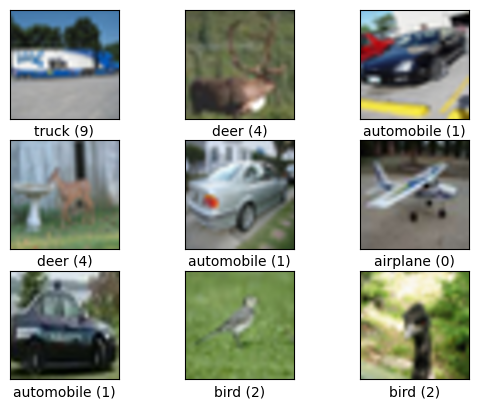

In [4]:
def get_train_valid_loader(data_dir='data',
                           batch_size=64,
                           augment=False,
                           random_seed=1,
                           valid_size=0.02,
                           shuffle=True,
                           show_sample=True,
                           num_workers=4,
                           pin_memory=False):
    """
    Utility function for loading and returning train and valid
    multi-process iterators over the CIFAR-10 dataset. A sample
    9x9 grid of the images can be optionally displayed.
    If using CUDA, num_workers should be set to 1 and pin_memory to True.
    Params
    ------
    - data_dir: path directory to the dataset.
    - batch_size: how many samples per batch to load.
    - augment: whether to apply the data augmentation scheme
      mentioned in the paper. Only applied on the train split.
    - random_seed: fix seed for reproducibility.
    - valid_size: percentage split of the training set used for
      the validation set. Should be a float in the range [0, 1].
    - shuffle: whether to shuffle the train/validation indices.
    - show_sample: plot 9x9 sample grid of the dataset.
    - num_workers: number of subprocesses to use when loading the dataset.
    - pin_memory: whether to copy tensors into CUDA pinned memory. Set it to
      True if using GPU.
    Returns
    -------
    - train_loader: training set iterator.
    - valid_loader: validation set iterator.
    """
    error_msg = "[!] valid_size should be in the range [0, 1]."
    assert ((valid_size >= 0) and (valid_size <= 1)), error_msg

    normalize = transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010],
    )

    # define transforms for validation (no augmentation)
    valid_transform = transforms.Compose([
        transforms.ToTensor(),
        normalize,
    ])

    # Define the transform for training (and data augmentation)
    train_transform = transforms.Compose([
        transforms.RandomCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize,
    ])

    # load the dataset
    train_dataset = datasets.CIFAR10(
        root=data_dir, train=True,
        download=True, transform=train_transform,
    )

    valid_dataset = datasets.CIFAR10(
        root=data_dir, train=True,
        download=True, transform=valid_transform,
    )

    num_train = len(train_dataset)
    indices = list(range(num_train))
    split = int(np.floor(valid_size * num_train))

    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)

    train_idx, valid_idx = indices[split:], indices[:split]
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, sampler=train_sampler,
        num_workers=num_workers, pin_memory=pin_memory,
    )
    valid_loader = torch.utils.data.DataLoader(
        valid_dataset, batch_size=batch_size, sampler=valid_sampler,
        num_workers=num_workers, pin_memory=pin_memory,
    )

    # visualize some images if requested
    if show_sample:
        sample_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=9, shuffle=shuffle,
            num_workers=num_workers, pin_memory=pin_memory,
        )
        data_iter = iter(sample_loader)
        images, labels = next(data_iter)
        # Unnormalize the images for display
        mean = [0.4914, 0.4822, 0.4465]
        std = [0.2023, 0.1994, 0.2010]
        unnorm_images = [unnormalize(img, mean, std) for img in images]
        X = torch.stack(unnorm_images).numpy().transpose([0, 2, 3, 1])
        plot_images(X, labels)

    return (train_loader, valid_loader)

def unnormalize(img, mean, std):
    img = img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
    return img

trainloader, valloader = get_train_valid_loader()

# Convolutional Neural Network Architecture

Please first review the CNN lecture and problem statement pdf to understand the overall architecture of a CNN and how each dimension evolves after each layer, we'll take as example the first and famous CNN LeNet5 :
<figure align="center">
  <img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2021/10/image-17.png" alt="LeNet5 Architecture" width="600">
  <figcaption>Image credit: <a href="https://en.wikipedia.org">Wikipedia</a></figcaption>
</figure>

# **Theory - Part 1 (20%)**

Please answer the following questions to assess your understanding of what happens during the training and inference of a CNN.

If you find any of these questions challenging or have any doubts, feel free to ask a TA for guidance or hints on the solution.

## 1. First Layer Convolution

If we consider the input of LeNet5 to be CIFAR-10, what would be the shape of the parameters of the first convolutional layer (stride = 1)?

- **A.** `torch.Size([6, 1, 5, 5])`
- **B.** `torch.Size([6, 3, 3, 3])`
- **C.** `torch.Size([6, 1, 5, 5])`
- **D.** `torch.Size([6, 3, 5, 5])`

## Ans1: D

## 2. Subsampling Window

What is the shape of the subsampling window (stride = 2) for the second layer (between C1 and C2), and does this shape remain invariant regardless of the subsampling method (e.g., Avg pooling or Max pooling)?

- **A.** `2x2, yes it does`
- **B.** `3x3, no it doesn't`
- **C.** `2x2, no it doesn't`
- **D.** `yes, it does`


## Ans2: A

## 3. Backpropagation for Convolutional Filters

Do the filters in the convolutional layers also benefit from backpropagation?

## Ans3: 

Yes, convolutional filters also benefit from backpropagation. When training a network from scratch, backpropagation is applied through all layers, including convolutional layers. When fine-tuning a pretrained model, it’s common practice to freeze the convolutional layers and only adjust the weights in the fully connected output layer(s) though.

## 4. Role of the Fully-Connected Layer

Explain in your own words why it is necessary to have a fully-connected layer in the architecture.


## Ans4: 

In LeNet, the fully-connected layer performs classification, while the convolutional layers handle feature extraction. The fully-connected layer aggregates the features extracted by the convolutions to make predictions. More generally, this layer serves as a classifier in CNNs, and its size can be easily adjusted to fit different numbers of output classes, making the model adaptable to various tasks.

# **Coding(60%)**

## Build your own Convolutional Neural Network Architecture

## Different ways to improve the accuracy of your network :
- Change the number of convolutions and layers (you can take inspiration from internet as you as you cite the architecture)
- Change the optmizer / its hyperparameters
- Add new types of layers
- Do some data augmentation in the get_train_valid_loader function (flipped, cropped, uncentered images) cf. https://pytorch.org/vision/stable/transforms.html


### What I did
- Simple VGG-8 architecture which is a smaller version of VGG-16 introduced in [this paper](https://arxiv.org/abs/1409.1556), [this illustration](https://www.researchgate.net/figure/a-Schematic-of-the-VGG-8-model-used-for-classification-of-images-from-CIFAR-10-dataset_fig5_358745644) also shows a concrete version of VGG-8.
- Data augmentation using random croping and horizontal flips in addition to the given normalization.
- Loss function: Cross Entropy, fairly standard for multiclass classification tasks
- Optimizer: Classic Adam with standard learning rate and weight-decay for regularization did the job slightly better than SGD so no further optimization was done.

In [5]:
class ConvNet(nn.Module):
    def __init__(self, n_input_channels=3, n_output=10):
        super().__init__()
        ################################################################################
        # TODO:                                                                        #
        # Define 2 or more different layers of the neural network                      #
        ################################################################################
        # 3 Blocks with Conv + Conv + MaxPool
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # 32x32x64
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # 32x32x64
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)        # 16x16x64
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 16x16x128
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),# 16x16x128
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)         # 8x8x128
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1), # 8x8x256
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), # 8x8x256
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)         # 4x4x256
        )
        
        # Fully connected classifier
        self.fc_block = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),  # Flattened size: 256 * 4 * 4
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, n_output)
        )
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################

    def forward(self, x):
        ################################################################################
        # TODO:                                                                        #
        # Set up the forward pass that the input data will go through.                 #
        # A good activation function betweent the layers is a ReLu function.           #
        #                                                                              #
        # Note that the output of the last convolution layer should be flattened       #
        # before being inputted to the fully connected layer. We can flatten           #
        # Tensor `x` with `x.view`.                                                    #
        ################################################################################
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)
        x = self.fc_block(x)
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################

        return x

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
net = ConvNet().to(device)

################################################################################
# TODO:                                                                        #
# Choose an Optimizer that will be used to minimize the loss function.         #
# Choose a critera that measures the loss                                      #
################################################################################
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)

epochs = 10
steps = 0
running_loss = 0
print_every = 200
for e in range(epochs):
    start = time.time()
    for images, labels in iter(trainloader):

        steps += 1
        ################################################################################
        # TODO:                                                                        #
        # Run the training process                                                     #
        #                                                                              #
        #                                                                              #
        ################################################################################
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = net(images)
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################

        loss = criterion(output, labels)
        ################################################################################
        # TODO:                                                                        #
        # Run the training process                                                     #
        #                                                                              #
        # HINT: Calculate the gradient and move one step further                       #
        ################################################################################
        loss.backward()
        optimizer.step()
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################

        running_loss += loss.item()

        if steps % print_every == 0:
            stop = time.time()
            
            # Test accuracy
            net.eval()
            accuracy = 0
            total = 0

            for ii, (images, labels) in enumerate(valloader):
            ################################################################################
            # TODO:                                                                        #
            # Calculate the accuracy                                                       #
            ################################################################################
                with torch.no_grad():
                    # do forward pass without taking gradients
                    images, labels = images.to(device), labels.to(device)
                    outputs = net(images)
                    # get the predicted label and compute accuracy
                    _, predicted = torch.max(outputs.data, 1)
                    accuracy += (predicted == labels).sum().item()
                    total += labels.size(0)

            # Note: I corrected the accuracy calculation
            accuracy = accuracy/total
            ################################################################################
            #                              END OF YOUR CODE                                #
            ################################################################################

            print("Epoch: {}/{}..".format(e+1, epochs),
                  "Loss: {:.4f}..".format(running_loss/print_every),
                  "Validation accuracy: {:.4f}..".format(accuracy),
                  "{:.4f} s/batch".format((stop - start)/print_every)
                 )
            
            running_loss = 0
            net.train()
            start = time.time()

device: cuda
Epoch: 1/10.. Loss: 1.9238.. Validation accuracy: 0.3390.. 0.0191 s/batch
Epoch: 1/10.. Loss: 1.5619.. Validation accuracy: 0.4590.. 0.0122 s/batch
Epoch: 1/10.. Loss: 1.3301.. Validation accuracy: 0.5140.. 0.0129 s/batch
Epoch: 2/10.. Loss: 1.1684.. Validation accuracy: 0.5850.. 0.0032 s/batch
Epoch: 2/10.. Loss: 1.0509.. Validation accuracy: 0.6400.. 0.0120 s/batch
Epoch: 2/10.. Loss: 0.9527.. Validation accuracy: 0.6740.. 0.0124 s/batch
Epoch: 2/10.. Loss: 0.9122.. Validation accuracy: 0.6840.. 0.0127 s/batch
Epoch: 3/10.. Loss: 0.8311.. Validation accuracy: 0.7090.. 0.0064 s/batch
Epoch: 3/10.. Loss: 0.7599.. Validation accuracy: 0.7210.. 0.0140 s/batch
Epoch: 3/10.. Loss: 0.7423.. Validation accuracy: 0.7340.. 0.0130 s/batch
Epoch: 3/10.. Loss: 0.7166.. Validation accuracy: 0.7380.. 0.0122 s/batch
Epoch: 4/10.. Loss: 0.6659.. Validation accuracy: 0.7550.. 0.0074 s/batch
Epoch: 4/10.. Loss: 0.6207.. Validation accuracy: 0.7420.. 0.0125 s/batch
Epoch: 4/10.. Loss: 0.621

Save best trained model.

In [7]:
## You should be familiar with how to save a pytorch model (Make sure to save the model in your Drive)
torch.save(net.state_dict(), 'net.pth')

# reload model and get overall accuracy
model = ConvNet().to(device)
model.load_state_dict(torch.load('net.pth', weights_only=True))

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in valloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

# get number of parameters
print(f"Model size: {sum(p.numel() for p in model.parameters() if p.requires_grad)} parameters")

Validation Accuracy: 83.10%
Model size: 3376970 parameters


# Some visualisations and Interpretation questions
This code allows us to look at the filters of the first layer of convolution :

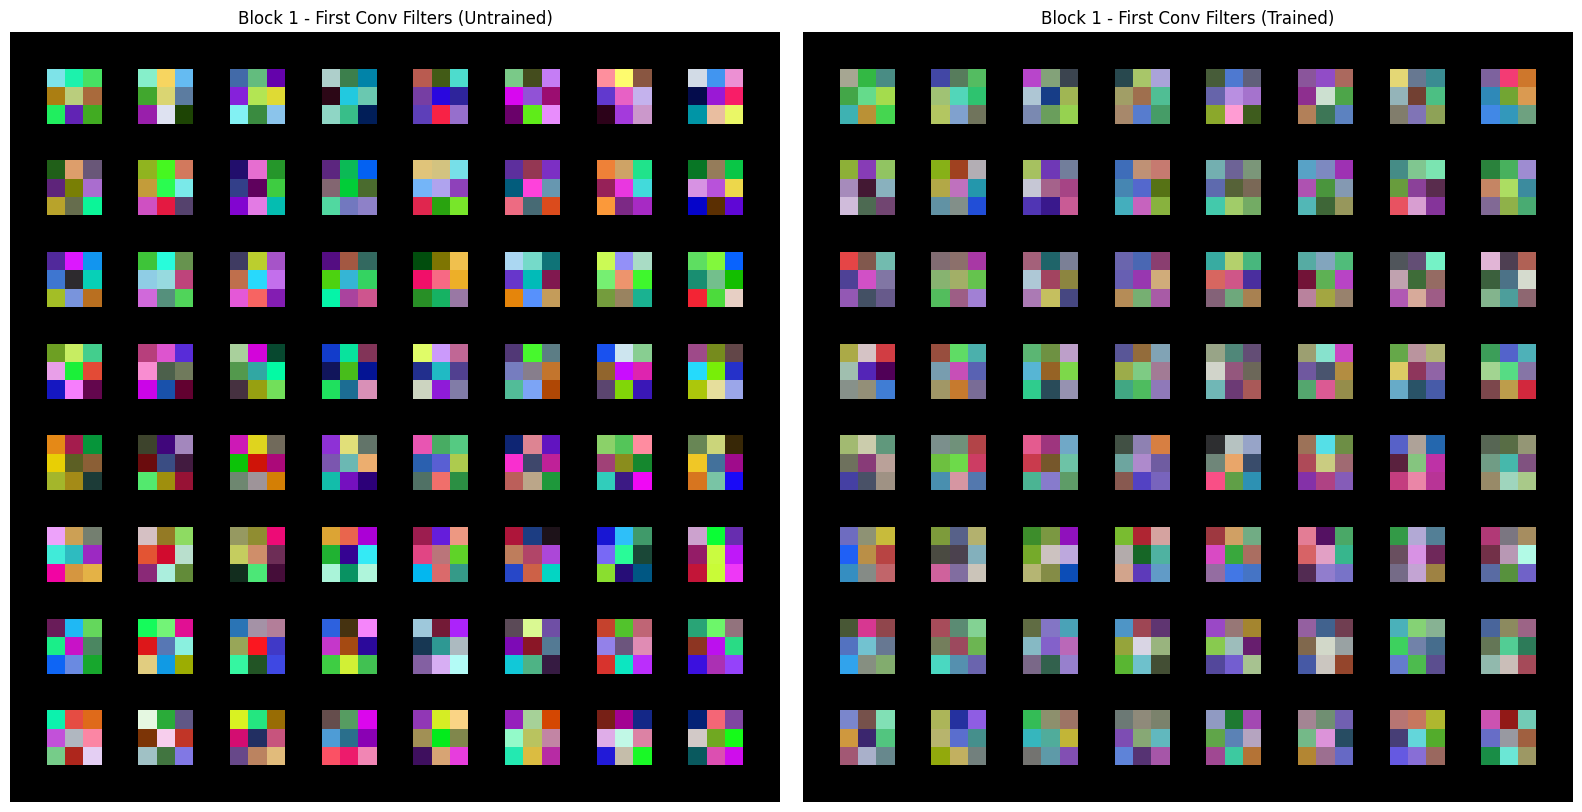

untrained filters: mean: 0.5044515132904053, std: 0.2886671721935272
trained filters: mean: 0.5155357718467712, std: 0.19533857703208923


In [8]:
def visualize_filters(layer, title='Filters'):
    filters = layer.weight.data.clone().cpu()
    filters = (filters - filters.min()) / (filters.max() - filters.min())
    grid = vutils.make_grid(filters, nrow=8, padding=2)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()

model = ConvNet() # Untrained model

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Untrained filters ---
filters_untrained = model.conv_block1[0].weight.data.clone().cpu()
filters_untrained = (filters_untrained - filters_untrained.min()) / (filters_untrained.max() - filters_untrained.min())
grid_untrained = vutils.make_grid(filters_untrained, nrow=8, padding=2)
axes[0].imshow(grid_untrained.permute(1, 2, 0))
axes[0].set_title("Block 1 - First Conv Filters (Untrained)")
axes[0].axis("off")

# --- Trained filters ---
filters_trained = net.conv_block1[0].weight.data.clone().cpu()
filters_trained = (filters_trained - filters_trained.min()) / (filters_trained.max() - filters_trained.min())
grid_trained = vutils.make_grid(filters_trained, nrow=8, padding=2)
axes[1].imshow(grid_trained.permute(1, 2, 0))
axes[1].set_title("Block 1 - First Conv Filters (Trained)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"untrained filters: mean: {filters_untrained.mean()}, std: {filters_untrained.std()}")
print(f"trained filters: mean: {filters_trained.mean()}, std: {filters_trained.std()}")

#### What do you notice about the filters after the training ? Try to find an interpretation about it.

The filters start with a random initialization, with a mean of about 0.50 and a standard deviation of 0.29. After training, the mean remains similar (around 0.51), but the standard deviation decreases to 0.21. This shows that while the filter values stay in a similar range, they become more stable and less varied. Visually, the filters shift from random patterns to smoother, more structured ones, reflecting common image features like edges and textures. The colors become more consistent with those found in actual images, which makes sense as the model learns to extract useful information.

### Activation maps
This code snippet uses a forward hook to capture the output of the first convolutional layer of a CNN when a sample image is passed through it. The resulting activation maps show how each filter in the layer responds to different regions or features in the image.

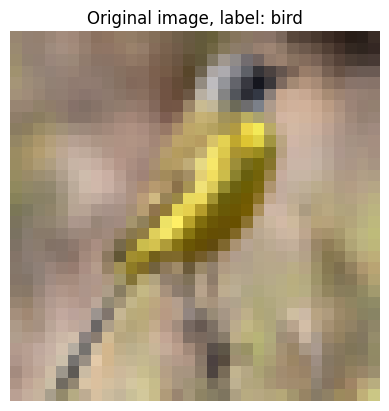

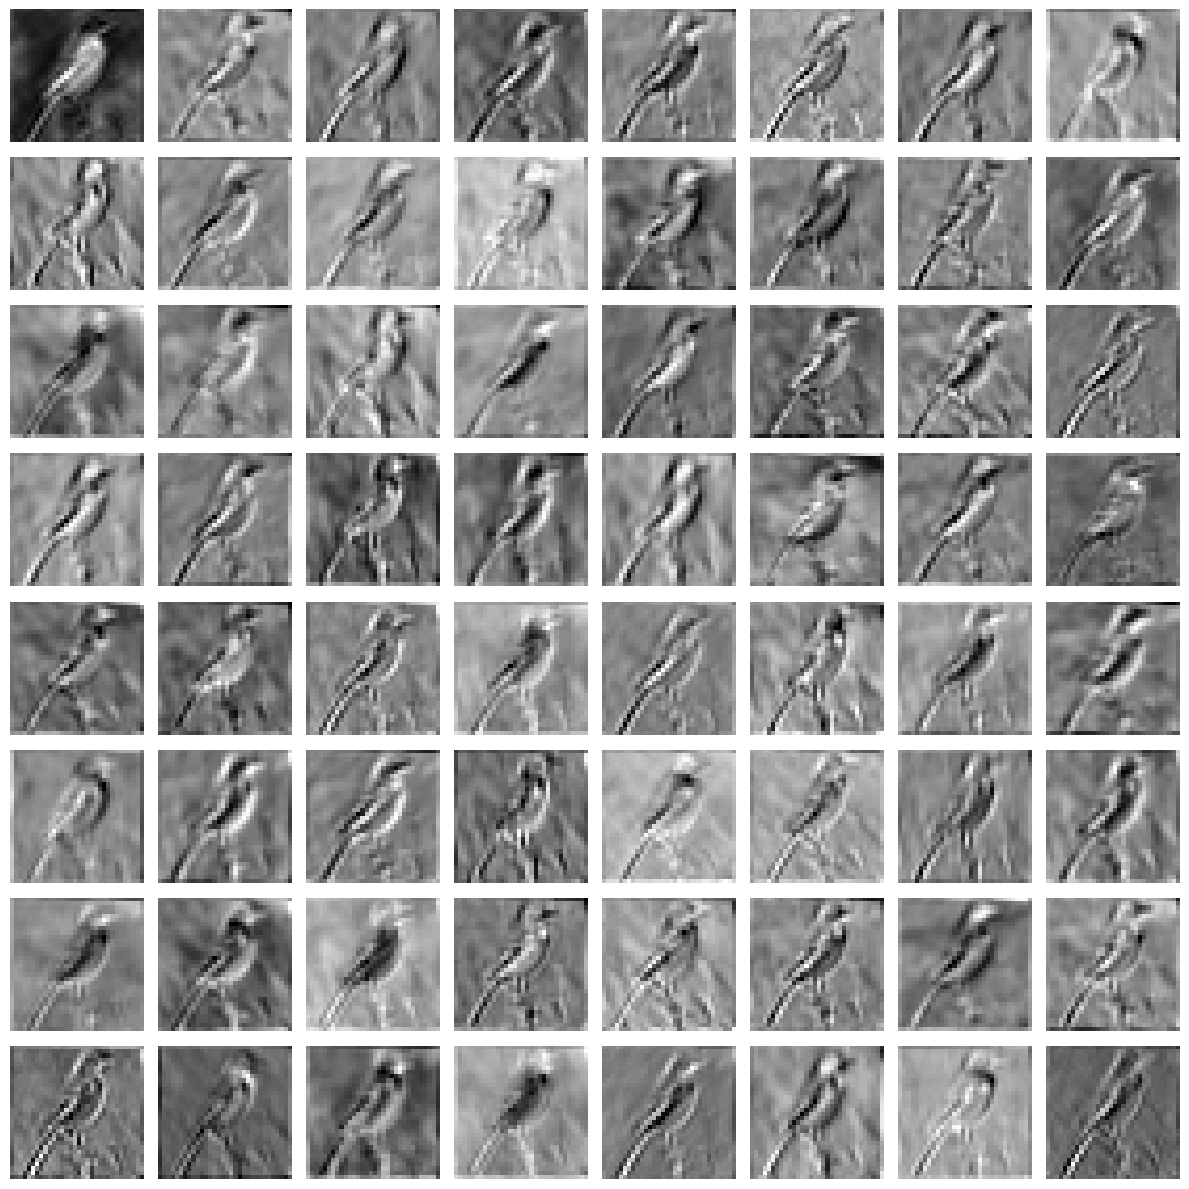

In [11]:
def get_activation(model, layer, x, device):
    activation = {}
    model.to(device)
    def hook_fn(module, input, output):
        activation['output'] = output.detach()
    hook = layer.register_forward_hook(hook_fn)
    x = x.to(device)
    model(x)
    hook.remove()
    return activation['output']

data_iter = iter(trainloader)
sample_images, sample_labels = next(data_iter)
sample_img = sample_images[0].unsqueeze(0).to(device)

# Get the feature maps after the first convolution (for example)
activation = get_activation(net, net.conv_block1[0], sample_img, device)

# Visualize a few feature maps in RGB:
def plot_feature_maps(feature_maps, n_cols=8):
    feature_maps = feature_maps.cpu()
    n_features = feature_maps.shape[1]
    n_rows = (n_features + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5))
    for i in range(n_features):
        plt.subplot(n_rows, n_cols, i + 1)
        # Extract the i-th feature map from the first (and only) sample in the batch
        act = feature_maps[0, i, :, :]
        # Normalize the activation map to [0, 1]
        act_norm = (act - act.min()) / (act.max() - act.min() + 1e-8)
        # Repeat the single channel 3 times to form an RGB image
        act_rgb = act_norm.unsqueeze(0).repeat(3, 1, 1)
        plt.imshow(act_rgb.permute(1, 2, 0))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

image = sample_img.squeeze(0).cpu().numpy()
image = (image - image.min()) / (image.max() - image.min())
plt.imshow(image.transpose(1, 2, 0))
plt.axis('off')
plt.title(f"Original image, label: {label_names[sample_labels[0]]}")
plt.show()

plot_feature_maps(activation, n_cols=8)

# Play with the index of the chosen sample to notice more patterns and answer the question

# **Theory - Part 2 (20%)**

Please answer the following questions based on your experience/observation during the training and inference of a CNN.

If you find any of these questions challenging or have any doubts, feel free to ask a TA for guidance or hints on the solution.


## 5. Feature Detection
What specific features do you observe in these activation maps? Do some maps clearly highlight edges, contours, or textures? How might these features relate to the overall structure of the sample (e.g., the outline of a horse)?

## Ans5:

In the first convolutional layer, the activation maps primarily highlight edges and changes in contrast. These features are important for detecting structures in the image, such as boundaries and outlines. As the network trains, these early features help the model understand more complex structures, like the contours or textures of objects in the image (e.g., the outline of a horse).

## 6. Effect of Training
Consider how the activations might change after training versus an untrained (random) network. What does this tell you about the learning process?

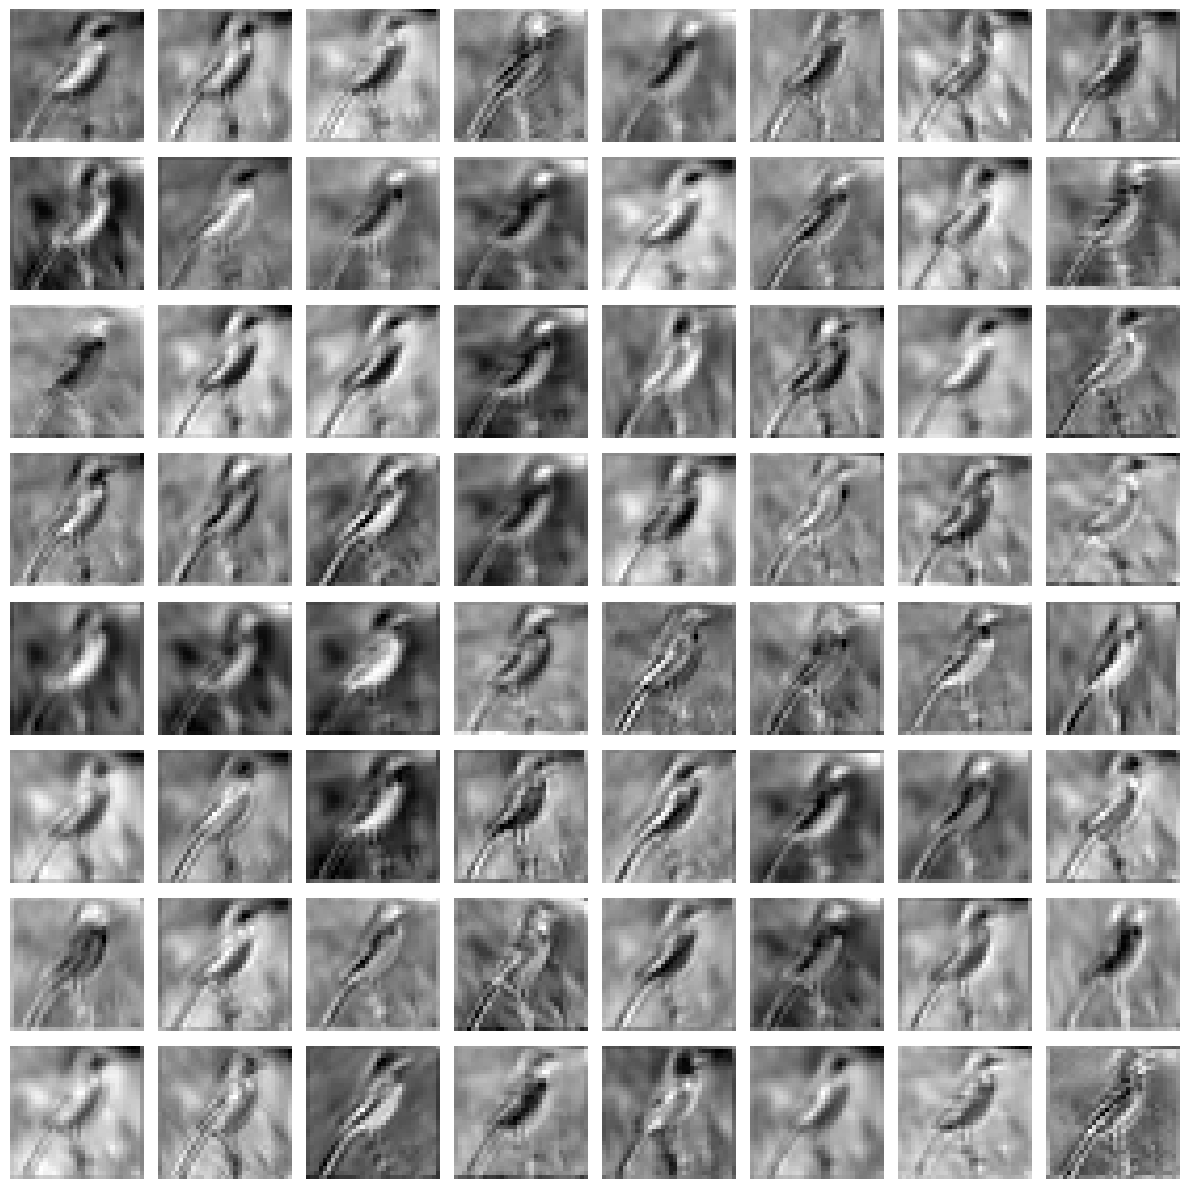

In [12]:
# Plot feature maps of untrained model
activation = get_activation(model, model.conv_block1[0], sample_img, device)

plot_feature_maps(activation, n_cols=8)

## Ans6:

We can see that the actvations of the untrained network are way more arbitrary and no clear structure is recognizable, most of the filters just seem to blur or darken the image considerably. So we can see that the training works and the network actually learns how to recognize different structures in the data. 